# Supplementary Figure 12.1: MNIST autoencoder training loss.

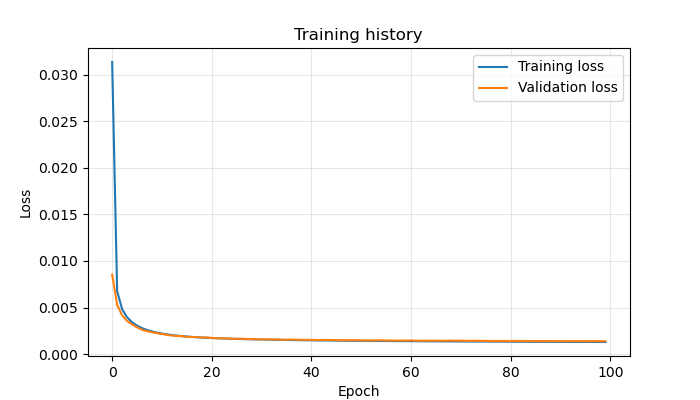

In [1]:
%matplotlib widget

import csv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
RESULTS_DIR = Path("..") / "data" / "mnist-ae"
LOG_CSV = RESULTS_DIR / "training_log.csv"

# Column names
COL_EPOCH = "epoch"
COL_LOSS = "loss"
COL_VAL_LOSS = "val_loss"

# ─────────────────────────────────────────────
# Load training log
# ─────────────────────────────────────────────
def load_training_log(csv_path):
    """Load training log CSV and return epochs, loss, and validation loss arrays."""
    epochs, loss, val_loss = [], [], []
    
    with open(csv_path, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        has_val = COL_VAL_LOSS in (reader.fieldnames or [])
        
        for row in reader:
            # Parse epoch (default to row index if missing/invalid)
            try:
                e = int(row.get(COL_EPOCH, len(epochs)))
            except (ValueError, TypeError):
                e = len(epochs)
            epochs.append(e)
            
            # Parse loss
            try:
                loss.append(float(row.get(COL_LOSS, "")))
            except (ValueError, TypeError):
                loss.append(np.nan)
            
            # Parse validation loss if present
            if has_val:
                try:
                    val_loss.append(float(row.get(COL_VAL_LOSS, "")))
                except (ValueError, TypeError):
                    val_loss.append(np.nan)
    
    return (np.array(epochs), 
            np.array(loss), 
            np.array(val_loss) if val_loss else None)

epochs, train_loss, val_loss = load_training_log(LOG_CSV)

# ─────────────────────────────────────────────
# Plot training history
# ─────────────────────────────────────────────
#| label: sfig12a_data
fig, ax = plt.subplots(figsize=(7, 4))
fig.canvas.header_visible = False

# Plot training loss
train_mask = np.isfinite(train_loss)
ax.plot(epochs[train_mask], train_loss[train_mask], label="Training loss")

# Plot validation loss if available
if val_loss is not None:
    val_mask = np.isfinite(val_loss)
    if val_mask.any():
        ax.plot(epochs[val_mask], val_loss[val_mask], label="Validation loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training history")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()